In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
from sklearn.linear_model import RANSACRegressor


In [2]:
# lambda functions to parse the vector and matrices from the string
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def fit_fl_fmc(fmc_srs:pd.Series, fl_srs:pd.Series):
  """
  Fit focus length against fmc for the data
  return: theta = [fl1, fl0]
  """
  X = np.vstack([fmc_srs, np.ones(fmc_srs.shape[0])]).T
  Y = fl_srs
  theta = np.linalg.inv(X.T @ X) @ X.T @ Y

  return theta

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_space)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_space)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_space)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_space)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

  return z_data

In [3]:
def get_fl(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->float:
  """
  Calculates the focal length using above linear model
  """
  # fmc = data_["fmc"][idx]
  # if (data_["cam"][idx][1] == "L"):
  #   return left_fl0 + left_fl1 * fmc
  # elif (data_["cam"][idx][1] == "R"):
  #   return right_fl0 + right_fl1 * fmc

  return data_["f_est"][idx]
  
def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray,
           left_fl0:float, left_fl1:float,
           right_fl0:float, right_fl1:float)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  # fl = data_["fl"][idx]
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray,
          left_fl0:float, left_fl1:float,
          right_fl0:float, right_fl1:float)->np.ndarray:
  # b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1)
  # fl = data_["fl"][idx]
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i

def get_q_rc_data(idx:int, data_: np.ndarray,
                  left_fl0:float, left_fl1:float,
                  right_fl0:float, right_fl1:float)->np.ndarray:
  """
  Forms the quaternion that corresponds to a rotation from r to c from data
  """
  H_r = get_H_r_data(idx, data_)
  H_c = get_KC(idx, data_, left_fl0, left_fl1, right_fl0, right_fl1).T
  return R.from_matrix(H_r @ np.linalg.inv(H_c)).as_quat()

def get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                  q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3,
                  q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3, 
                  idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the quaternion that corresponds to a rotation from r to c from model
  """
  rot_rrp = R.from_quat(np.array([q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3]))

  rot_rpm = R.from_matrix(get_R_rpm(idx, data_))

  rot_mc_0 = R.from_quat(np.array([q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3]))
  rot_mc_1 = R.from_quat(np.array([q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3]))
  f = data_["fmc"][idx]
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
  
  return (rot_rrp * rot_rpm * rot_mc).as_quat(canonical=True)

def get_c_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  c_i = np.expand_dims(data_["c_r_vec"][idx], axis=1)
  return c_i

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_R_mc(idx:int, data_:np.ndarray,
             q_cm_zl_0, q_cm_zl_1,
             q_cm_zr_0, q_cm_zr_1)->np.ndarray:
  """
  Rotation matrix going from mast frame to camera frame
  """
  f = data_["fmc"][idx]
  
  q_cm_0 = q_cm_zl_0 if data_["cam"][idx] == "ZL034" else q_cm_zr_0
  q_cm_1 = q_cm_zl_1 if data_["cam"][idx] == "ZR034" else q_cm_zr_1

  rot_mc_0 = R.from_quat(q_cm_0)
  rot_mc_1 = R.from_quat(q_cm_1)

  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))

  return rot_mc.as_matrix()

def get_t_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Translation vector going from r_prime to mast frame
  """
  return np.expand_dims(data_["t_rpm_vec"][idx], axis=1)


In [4]:
def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)

  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

def generate_rot_obj(left_fl0:float, left_fl1:float,
                 right_fl0:float, right_fl1:float,
                 zl_:pd.DataFrame, zr_:pd.DataFrame)->callable:
  """
  Generates the objective function for the optimization
  """

  data_ = pd.concat([zl_, zr_], axis=0).reset_index(drop=True)

  def obj(x)->float:
  
    q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
    q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
    q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3 = x[8:12]
    q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[12:16]
    q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3 = x[16:20]

    total_dist = 0
    count = 0
    for i in range(data_.shape[0]):
      q_rc_data = get_q_rc_data(i, data_, left_fl0, left_fl1, right_fl0, right_fl1)
      
      if data_["cam"][i][1] == "L":
        q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                    q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
                                    q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3,
                                    i, data_)
        total_dist += dist_q(q_rc_data, q_rc_model)
        count += 1
      
      elif data_["cam"][i][1] == "R":
        q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                    q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
                                    q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3,
                                    i, data_)
        total_dist += dist_q(q_rc_data, q_rc_model)
        count += 1
    
    return total_dist/count
  
  return obj

def dist_metric(c_r_data, c_r_model):
  return np.linalg.norm(c_r_data - c_r_model, ord=2)**2

def gen_trans_obj(q_rrp, zl, zr):

  data_ = pd.concat([zl, zr], axis=0).reset_index(drop=True)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  def obj(x):
    obj_val = 0
    count = 0
    t_rrp = np.expand_dims(x[:3], axis=1)
    t_mc_zl_0 = np.expand_dims(x[3:6], axis=1)
    t_mc_zl_1 = np.expand_dims(x[6:9], axis=1)
    t_mc_zr_0 = np.expand_dims(x[9:12], axis=1)
    t_mc_zr_1 = np.expand_dims(x[12:], axis=1)

    for i in range(data_.shape[0]):  
      # compute the data
      c_r_data = get_c_r_data(i, data_)

      # compute the model
      f = data_["fmc"][i]
      R_rpm = get_R_rpm(i, data_)
      t_mc = t_mc_zl_0 + f * t_mc_zl_1 if data_["cam"][i].startswith("ZL") else t_mc_zr_0 + f * t_mc_zr_1
      t_rpm = get_t_rpm(i, data_)
      
      

      c_r_model = R_rrp @ R_rpm @ t_mc + R_rrp @ t_rpm + t_rrp
      # c_r_model = np.expand_dims(c_r_model, axis=1)

      obj_val += dist_metric(c_r_data, c_r_model)
      count += 1
    
    return obj_val / count
  
  return obj



## Understanding $q^m_c$ for ZL048 and ZR048

In [5]:
f_str = "048"

data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data = pd.read_excel(data_fpath)


zl, zr = get_zl_zr(f_str, data)
parse_cahvor(zl)
parse_cahvor(zr)
print(f"Number of data points for zl{f_str}:\t{zl.shape[0]}")
print(f"Number of data points for zr{f_str}:\t{zr.shape[0]}")

Number of data points for zl048:	38
Number of data points for zr048:	248


## Focal Length Fitting

In [6]:
f_str = "048"

data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data = pd.read_excel(data_fpath)


zl, zr = get_zl_zr(f_str, data)
parse_cahvor(zl)
parse_cahvor(zr)
print(f"Number of data points for zl{f_str}:\t{zl.shape[0]}")
print(f"Number of data points for zr{f_str}:\t{zr.shape[0]}")

# filter out by fmc

# focus as a function of fmc
theta_l = fit_fl_fmc(zl["fmc"], zl["f_est"])
theta_r = fit_fl_fmc(zr["fmc"], zr["f_est"])

print(f"left fit: fl = {theta_l[1]:.6f} + {theta_l[0]:.6f} * fmc")
print(f"right fit: fl = {theta_r[1]:.6f} + {theta_r[0]:.6f} * fmc")



Number of data points for zl048:	38
Number of data points for zr048:	248
left fit: fl = 6647.466021 + 0.016380 * fmc
right fit: fl = 6589.613140 + 0.034197 * fmc


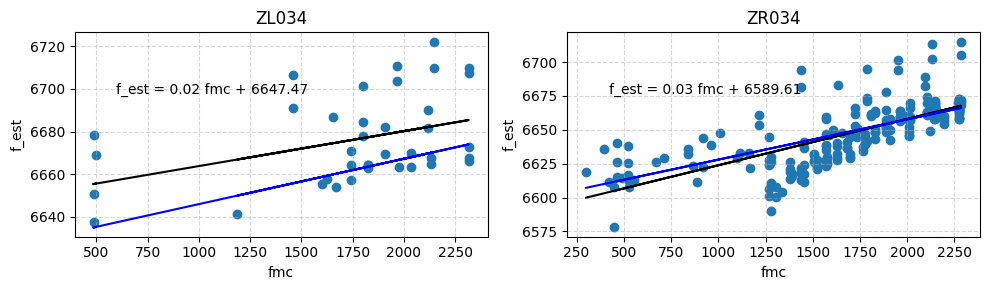

In [7]:

X_l =  np.vstack([zl["fmc"], np.ones(zl["f_est"].shape[0])]).T
X_r =  np.vstack([zr["fmc"], np.ones(zr["f_est"].shape[0])]).T


reg_l = RANSACRegressor(random_state=0).fit(X_l, zl["f_est"])
reg_r = RANSACRegressor(random_state=0).fit(X_r, zr["f_est"])


fig, ax = plt.subplots(1, 2, figsize=(10,3))


# left focal-length as a function of fmc

ax[0].scatter(zl["fmc"], zl["f_est"], label="f_est")
ax[0].plot(zl["fmc"], X_l @ theta_l, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_l), color="black")
ax[0].plot(zl["fmc"], reg_l.predict(X_l), color="blue")
ax[0].set_xlabel("fmc")
ax[0].set_ylabel("f_est")
ax[0].set_title("ZL034")
ax[0].grid(linestyle="--", alpha=0.5)
ax[0].text(0.1, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_l), transform=ax[0].transAxes)


# right focal-length as a function of fmc
ax[1].scatter(zr["fmc"], zr["f_est"], label="f_est")
ax[1].plot(zr["fmc"], X_r @ theta_r, label="f_est = {:.2f} fmc + {:.2f}".format(*theta_r), color="black")
ax[1].plot(zr["fmc"], reg_r.predict(X_r), color="blue", label="RANSAC fit")
ax[1].set_xlabel("fmc")
ax[1].set_ylabel("f_est")
ax[1].set_title("ZR034")
ax[1].grid(linestyle="--", alpha=0.5)
ax[1].text(0.1, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_r), transform=ax[1].transAxes)


plt.tight_layout()
plt.show()

## Rotation and translation Fitting

In [8]:
x0 = [ 0.001, 0.001,  0.001, 1,
      0.5, 0.5, 0.5, 0.5,
      0.01, 0.01, 0.01, 1,
      0.11, 0.64, 0.2, 0.72,
      0.01, 0.01, 0.01, 1]
# rot_obj = generate_rot_obj(reg_l.estimator_.coef_[0] , reg_l.estimator_.intercept_,
#                          reg_r.estimator_.coef_[0] , reg_r.estimator_.intercept_,
#                            zl, zr)
rot_obj = generate_rot_obj(theta_l[1] , theta_l[0], theta_r[1] , theta_r[0], zl, zr)

res = minimize(rot_obj, x0, method="BFGS", options={"return_all":True,
                                                "gtol":1e-20,
                                                "xrtol":1e-20,
                                                "maxiter":200})

In [9]:
q_rrp = np.array(res.x[:4])
q_cm_zl_0 = np.array(res.x[4:8])/np.linalg.norm(res.x[4:8])
q_cm_zl_1 = np.array(res.x[8:12])
q_cm_zr_0 = np.array(res.x[12:16])/np.linalg.norm(res.x[12:16])
q_cm_zr_1 = np.array(res.x[16:20])

print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:{q_rrp}")
print(f"q_cm_zl_0:{q_cm_zl_0}")
print(f"q_cm_zl_1:{q_cm_zl_1}")
print(f"q_cm_zr_0:{q_cm_zr_0}")
print(f"q_cm_zr_1:{q_cm_zr_1}")

rot_cm_zl_1_deg = R.from_quat(q_cm_zl_1).as_euler("xyz", degrees=True)
rot_cm_zr_1_deg = R.from_quat(q_cm_zr_1).as_euler("xyz", degrees=True)
print(f"rot_cm_zl_1_deg:{rot_cm_zl_1_deg}")
print(f"rot_cm_zr_1_deg:{rot_cm_zr_1_deg}")

Final function:0.038171
Final Jacobian:0.003960
q_rrp:[ 3.02010699e-04 -1.49266848e-03 -7.92022859e-03  9.58993160e-01]
q_cm_zl_0:[0.4612077  0.48417833 0.54386311 0.50702241]
q_cm_zl_1:[0.00966735 0.00645749 0.00677021 1.06138383]
q_cm_zr_0:[0.47631088 0.47697342 0.53528583 0.50901217]
q_cm_zr_1:[0.01120439 0.00812807 0.00826136 1.1699018 ]
rot_cm_zl_1_deg:[1.04814166 0.6904268  0.73724601]
rot_cm_zr_1_deg:[1.10305206 0.78826783 0.81677289]


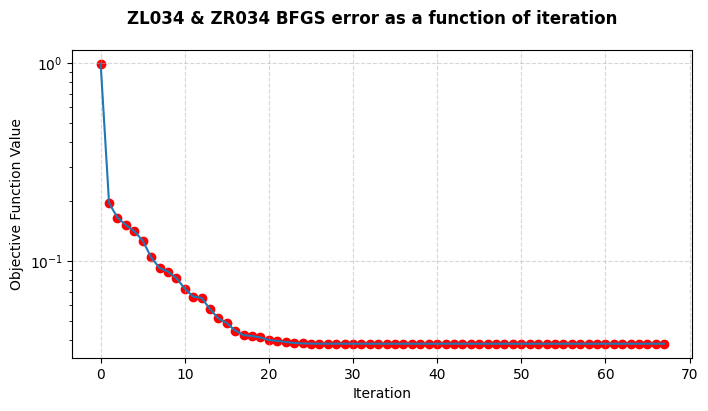

In [10]:
# plot the error as a function of iteration
errs = [rot_obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 & ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

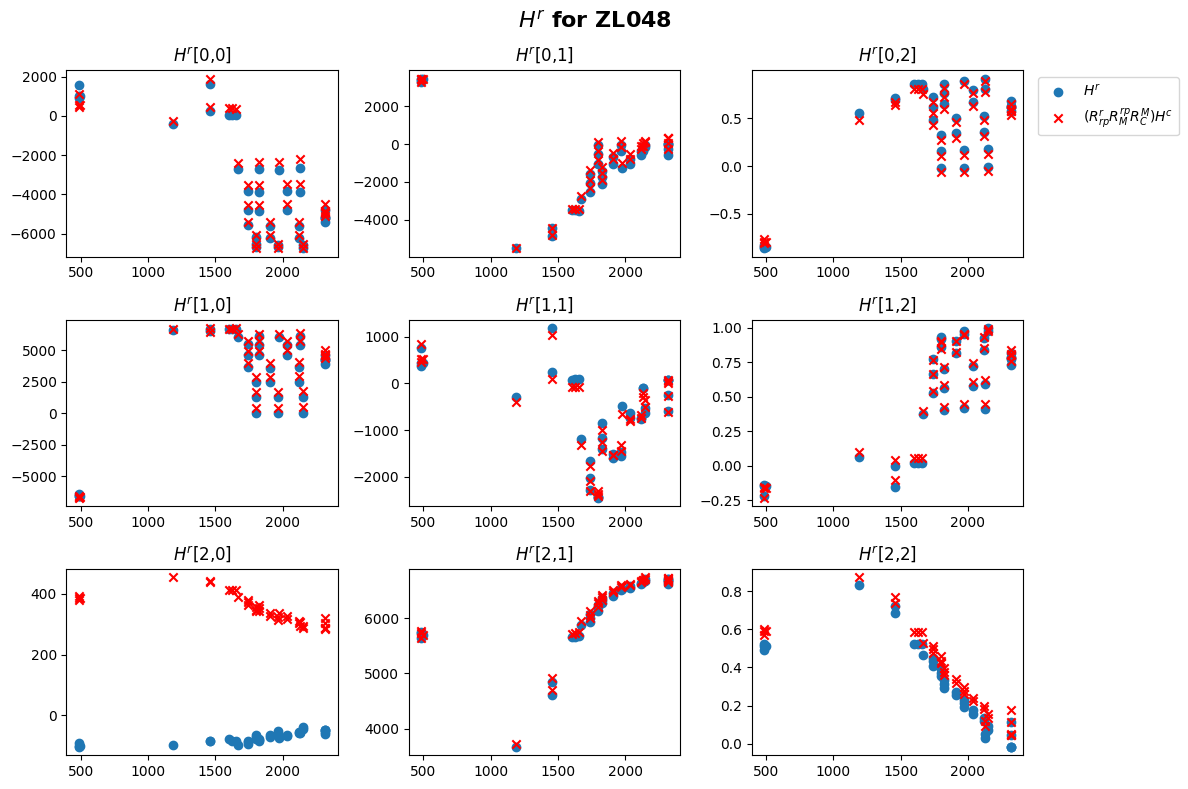

In [11]:
# plot H_r matrix as a function of f
H_r_data_zl = []
H_r_model_zl = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zl.shape[0]):
 # compute the rotation R_rpm
  rot_rpm = R.from_matrix(get_R_rpm(i, zl))
  
  # slerp between q_cm_zl_a and q_cm_zl_b
  f = zl["fmc"][i]
  rot_mc_0 = R.from_quat(q_cm_zl_0)
  rot_mc_1 = R.from_quat(q_cm_zl_1)
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))

  # compute R_rc 
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()
  
  H_c = get_KC(i, zl, theta_l[1], theta_l[0], theta_r[1], theta_r[0]).T
  H_r_model_zl.append(R_rc @ H_c)

  # data
  H_r_data_zl.append(get_H_r_data(i, zl))

fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl["fmc"], [H[r,c] for H in H_r_data_zl], label="expectation")
    ax[r,c].scatter(zl["fmc"], [H[r, c] for H in H_r_model_zl], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) H^c$"], bbox_to_anchor=(1.6,1))
fig.suptitle(f"$H^r$ for ZL{f_str}", fontsize=16, fontweight="bold")
fig.tight_layout()

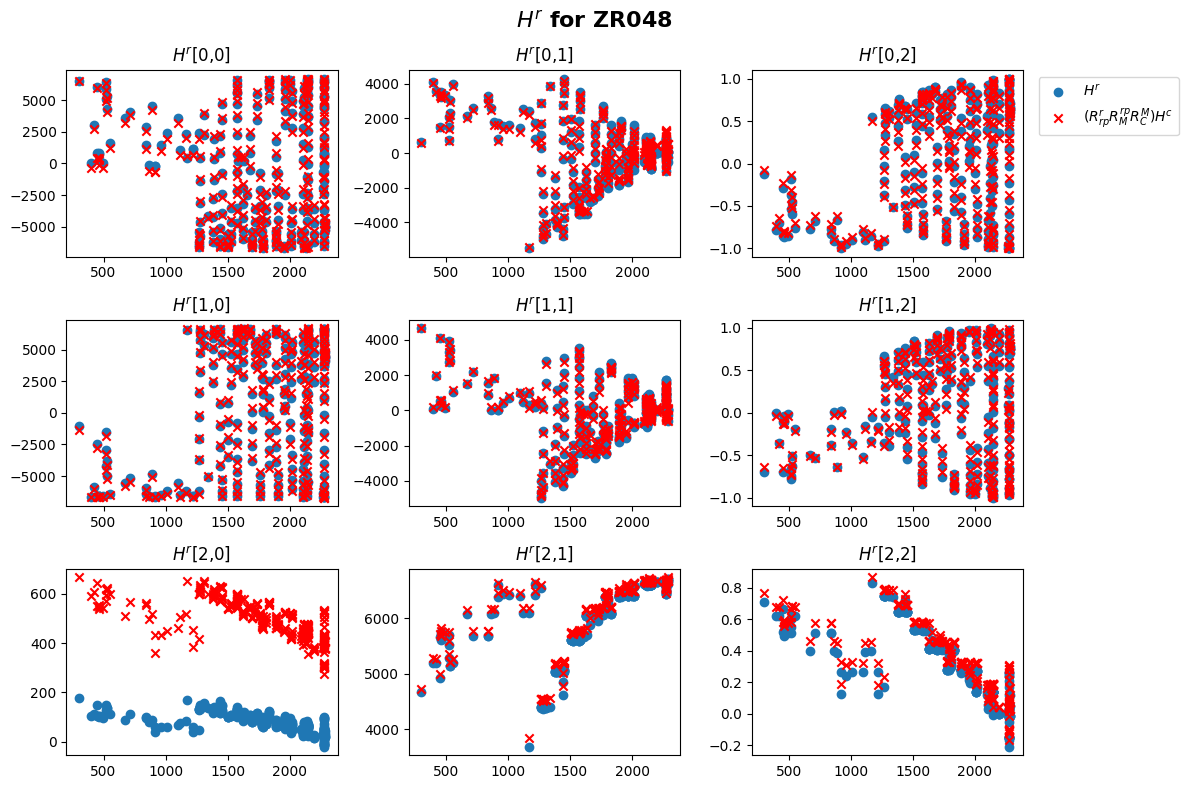

In [15]:
# plot H_r matrix as a function of f
H_r_data_zr = []
H_r_model_zr = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zr.shape[0]):
 # compute the rotation R_rpm
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  
  # slerp between q_cm_zl_a and q_cm_zl_b
  f = zr["fmc"][i]
  rot_mc_0 = R.from_quat(q_cm_zr_0)
  rot_mc_1 = R.from_quat(q_cm_zr_1)
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))

  # compute R_rc 
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()
  
  H_c = get_KC(i, zr, theta_l[1], theta_l[0], theta_r[1], theta_r[0]).T
  H_r_model_zr.append(R_rc @ H_c)

  # data
  H_r_data_zr.append(get_H_r_data(i, zr))

fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr["fmc"], [H[r,c] for H in H_r_data_zr], label="expectation")
    ax[r,c].scatter(zr["fmc"], [H[r, c] for H in H_r_model_zr], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) H^c$"], bbox_to_anchor=(1.6,1))
fig.suptitle(f"$H^r$ for ZR{f_str}", fontsize=16, fontweight="bold")
fig.tight_layout()

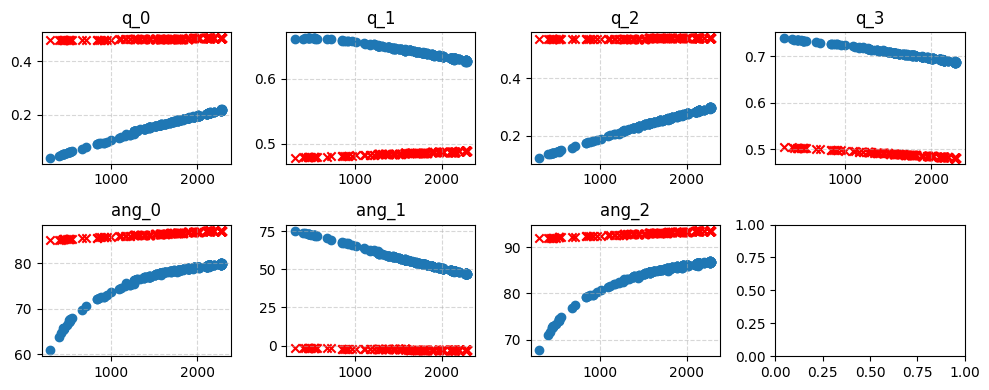

In [16]:
# plot H_r matrix as a function of f
q_mc_zr = []
ang_mc_zr = []
q_mc_model_zr = []
ang_mc_model_zr = []

# rot_rrp = R.from_quat([5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01])
rot_rrp = R.from_quat(q_rrp)
rot_mc_zr_0 = R.from_quat(q_cm_zr_0)
rot_mc_zr_1 = R.from_quat(q_cm_zr_1)
for i in range(zr.shape[0]):
 # compute the rotation R_rpm
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  rot_rm = rot_rrp * rot_rpm
  R_rm = rot_rm.as_matrix()
  
  b1, b2 = zr["b1_est"][i], zr["b2_est"][i]
  cx, cy = zr["cx_est"][i], zr["cy_est"][i]
  fl = zr["fmc"][i]
  Hc = np.array([[fl+b1, b2, cx],
                 [0, fl, cy],
                 [0, 0, 1]]).T

  Hr = get_H_r_data(i, zr)
  
  R_mc = R_rm.T @ Hr @ np.linalg.inv(Hc)
  q_mc_zr_i = R.from_matrix(R_mc).as_quat(canonical=True)
  
  q_mc_zr.append(q_mc_zr_i/np.linalg.norm(q_mc_zr_i))
  ang_mc_zr.append(R.from_matrix(R_mc).as_euler("xyz", degrees=True))

  rot_mc = rot_mc_zr_0 * (rot_mc_zr_1**(fl/1000))
  q_mc_model_zr.append(rot_mc.as_quat())
  ang_mc_model_zr.append(rot_mc.as_euler("xyz", degrees=True))

fig, ax = plt.subplots(2, 4, figsize=(10,4))

for i in range(4):
  ax[0, i].scatter(zr["fmc"], [q[i] for q in q_mc_zr])
  ax[0, i].scatter(zr["fmc"], [q[i] for q in q_mc_model_zr], color="red", marker="x")
  ax[0, i].set_title(f"q_{i}")
  ax[0, i].grid(linestyle="--", alpha=0.5)

  if i<3:
    ax[1, i].scatter(zr["fmc"], [a[i] for a in ang_mc_zr])
    ax[1, i].scatter(zr["fmc"], [a[i] for a in ang_mc_model_zr], color="red", marker="x")
    ax[1, i].set_title(f"ang_{i}")
    ax[1, i].grid(linestyle="--", alpha=0.5)

fig.tight_layout()

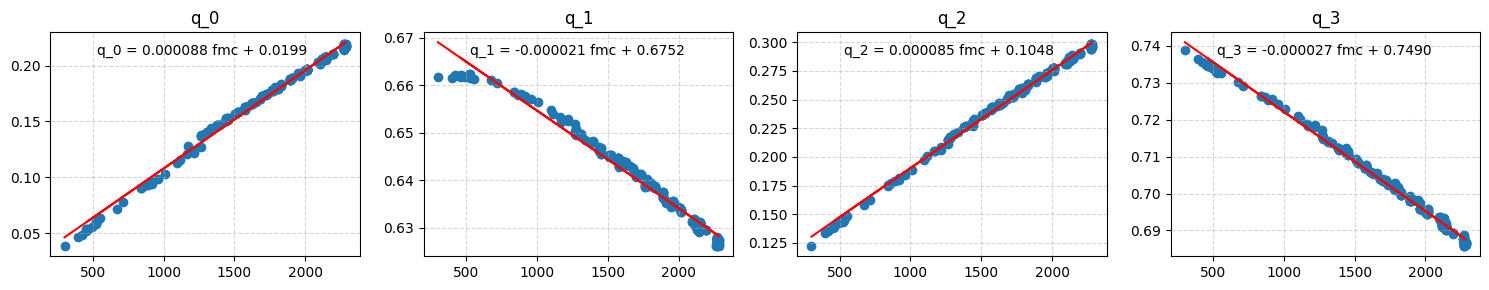

In [28]:
# for each component in q_mc_zr, fit a linear model

X_r = np.vstack([zr["fmc"], np.ones(zr["fmc"].shape[0])]).T

q_mc_zr_models = []
for i in range(4):
  q_i = np.array([q[i] for q in q_mc_zr])
  theta = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ q_i
  q_mc_zr_models.append(theta)


fig, ax = plt.subplots(1, 4, figsize=(15,3))

for i in range(4):
  ax[i].scatter(zr["fmc"], [q[i] for q in q_mc_zr])
  ax[i].plot(zr["fmc"], X_r @ q_mc_zr_models[i], color="red")
  ax[i].set_title(f"q_{i}")
  ax[i].grid(linestyle="--", alpha=0.5)
  ax[i].text(0.15, 0.9, "q_{:d} = {:.6f} fmc + {:.4f}".format(i, *q_mc_zr_models[i]), transform=ax[i].transAxes)

fig.tight_layout()

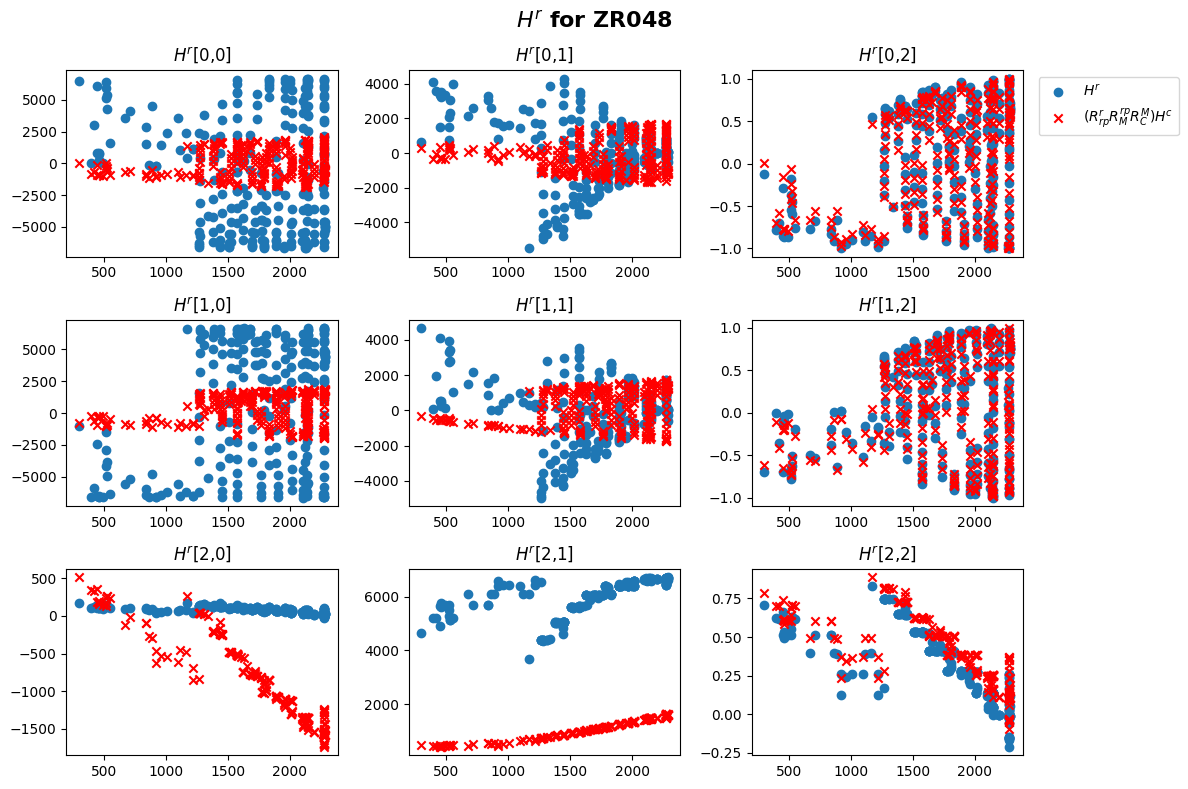

In [13]:
# plot H_r matrix as a function of f
H_r_data_zr = []
H_r_model_zr = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zr.shape[0]):
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  rot_rm = rot_rrp * rot_rpm
  R_rm = rot_rm.as_matrix()
  
  b1, b2 = zr["b1_est"][i], zr["b2_est"][i]
  cx, cy = zr["cx_est"][i], zr["cy_est"][i]
  fl = zr["fmc"][i]
  Hc = np.array([[fl+b1, b2, cx],
                 [0, fl, cy],
                 [0, 0, 1]]).T

  Hr = get_H_r_data(i, zr)
  
  R_mc = R_rm.T @ Hr @ np.linalg.inv(Hc)
  q_mc_zr_i = R.from_matrix(R_mc).as_quat(canonical=True)


  rot_mc = R.from_quat(q_mc_zr_i)

  # compute R_rc 
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()
  
  # H_c = get_KC(i, zr, theta_l[1], theta_l[0], theta_r[1], theta_r[0]).T
  H_r_model_zr.append(R_rc @ Hc)

  # data
  H_r_data_zr.append(get_H_r_data(i, zr))

fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr["fmc"], [H[r,c] for H in H_r_data_zr], label="expectation")
    ax[r,c].scatter(zr["fmc"], [H[r, c] for H in H_r_model_zr], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) H^c$"], bbox_to_anchor=(1.6,1))
fig.suptitle(f"$H^r$ for ZR{f_str}", fontsize=16, fontweight="bold")
fig.tight_layout()

In [33]:
q_mc_0 = np.array([model[1] for model in q_mc_zr_models])
q_mc_1 = np.array([model[0] for model in q_mc_zr_models])

print(q_mc_0)
print(q_mc_0/np.linalg.norm(q_mc_0))
print(q_mc_1)

[0.01994159 0.67517823 0.10483173 0.74898802]
[0.01966588 0.66584328 0.10338234 0.73863257]
[ 8.79037179e-05 -2.05271131e-05  8.53813727e-05 -2.68769912e-05]


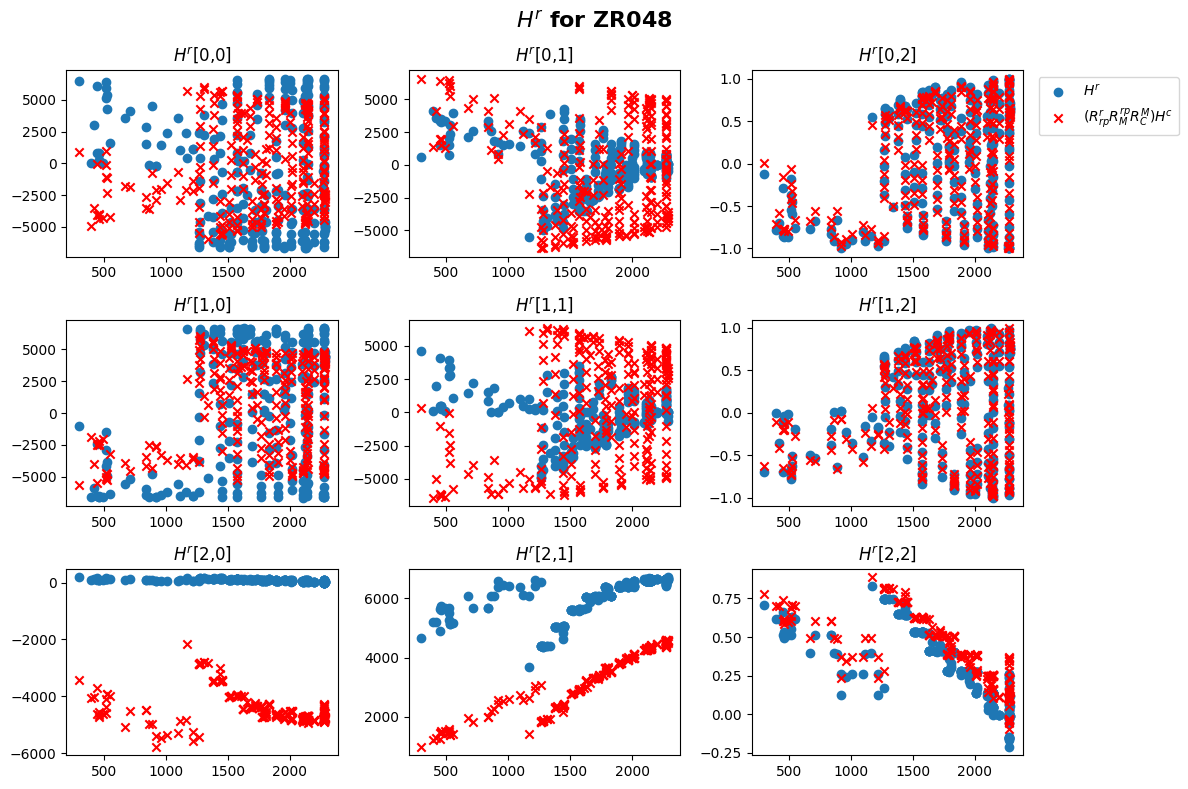

In [30]:
q_mc_0 = np.array([model[1] for model in q_mc_zr_models])
q_mc_1 = np.array([model[0] for model in q_mc_zr_models])

# plot H_r matrix as a function of f
H_r_data_zr = []
H_r_model_zr = []

rot_rrp = R.from_quat(q_rrp)

for i in range(zr.shape[0]):
 # compute the rotation R_rpm
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  
  # slerp between q_cm_zl_a and q_cm_zl_b
  f = zr["fmc"][i]
  rot_mc = R.from_quat(q_mc_0 + f * q_mc_1)

  # compute R_rc 
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()
  
  H_c = get_KC(i, zr, theta_l[1], theta_l[0], theta_r[1], theta_r[0]).T
  H_r_model_zr.append(R_rc @ H_c)

  # data
  H_r_data_zr.append(get_H_r_data(i, zr))

fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr["fmc"], [H[r,c] for H in H_r_data_zr], label="expectation")
    ax[r,c].scatter(zr["fmc"], [H[r, c] for H in H_r_model_zr], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) H^c$"], bbox_to_anchor=(1.6,1))
fig.suptitle(f"$H^r$ for ZR{f_str}", fontsize=16, fontweight="bold")
fig.tight_layout()

In [27]:
x0 = [0,0,0,
      0.03, 0.124, 0.07, 0, 0, 0,
      0.036, 0.119, 0.067, 0, 0, 0]

tans_obj = gen_trans_obj(q_rrp, zl, zr)
res = minimize(tans_obj, x0, method="BFGS", options={"return_all":True,
                                                "gtol":1e-20,
                                                "xrtol":1e-20})

t_rrp = np.expand_dims(res.x[:3],axis=1)
t_mc_zl_0 = np.expand_dims(res.x[3:6], axis=1)
t_mc_zl_1 = np.expand_dims(res.x[6:9], axis=1)
t_mc_zr_0 = np.expand_dims(res.x[9:12], axis=1)
t_mc_zr_1 = np.expand_dims(res.x[12:], axis=1)

print(res.fun)
print(f"t_rrp: {res.x[:3]}")
print(f"t_mc_zl_0: {res.x[3:6]}")
print(f"t_mc_zl_1: {res.x[6:9]}")
print(f"t_mc_zr_0: {res.x[9:12]}")
print(f"t_mc_zr_1: {res.x[12:]}")

1.2180726436634322e-05
t_rrp: [ 0.00031858 -0.00087478 -0.00161427]
t_mc_zl_0: [ 0.03434304 -0.12438026 -0.06456058]
t_mc_zl_1: [-1.97483698e-07  4.35432521e-07  5.64975155e-07]
t_mc_zr_0: [ 0.03759756  0.11933682 -0.06414494]
t_mc_zr_1: [1.79088857e-06 5.82586990e-07 5.10291986e-07]


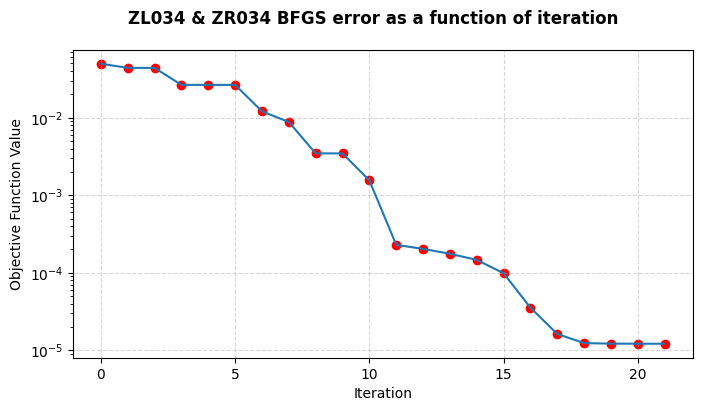

In [28]:
# plot the error as a function of iteration
errs = [tans_obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 & ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");